# Residents Table EDA

Focus: enrollment lifecycle, population profile, and business signals from resident-level data.


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BASE_DIR = Path('..').resolve() / 'data'
residents = pd.read_parquet(BASE_DIR / 'residents.parquet').copy()
for c in ['admission_date', 'discharge_date', 'deceased_date', 'date_of_birth']:
    if c in residents.columns:
        residents[c] = pd.to_datetime(residents[c], errors='coerce')

print('shape:', residents.shape)
residents.head()


shape: (3000, 9)


,resident_id,facility_id,date_of_birth,admission_date,discharge_date,deceased_date,outpatient,created_at,updated_at
0,578b8ad7-37c2-52b2-8b9e-9d82891ddf41,018d5b79-b86a-5dc8-8453-417d99a8f1f9,1936-04-15,2017-10-25 23:00:00,NaT,NaT,False,2024-12-17 09:44:08.250,2026-02-13 04:51:18.257
1,a13b0271-693e-589a-aac3-8cdbc200229b,018d5b79-b86a-5dc8-8453-417d99a8f1f9,1953-08-08,2021-09-15 23:00:00,NaT,NaT,False,2024-12-17 09:44:28.970,2026-02-10 04:49:02.887
2,9a2f39bf-23c2-580b-b17c-8575e8c89446,018d5b79-b86a-5dc8-8453-417d99a8f1f9,1963-07-11,2024-11-28 00:00:00,NaT,NaT,False,2024-12-17 09:44:07.793,2026-02-15 08:54:49.493
3,8683d1dd-7f25-5d2a-9888-50459db11849,018d5b79-b86a-5dc8-8453-417d99a8f1f9,1964-07-25,2024-09-17 23:00:00,2024-12-20 20:46:00,NaT,False,2024-12-17 09:44:43.297,2025-11-20 06:29:39.887
4,2b208db4-43fa-5683-9bca-78dcce0589af,018d5b79-b86a-5dc8-8453-417d99a8f1f9,1959-12-27,2024-11-07 23:00:00,2025-03-01 09:58:00,NaT,False,2024-12-17 09:44:17.947,2025-11-20 06:29:39.887


In [2]:
summary = {
    'rows': len(residents),
    'unique_residents': residents['resident_id'].nunique() if 'resident_id' in residents.columns else np.nan,
    'unique_facilities': residents['facility_id'].nunique() if 'facility_id' in residents.columns else np.nan,
    'admission_min': residents['admission_date'].min() if 'admission_date' in residents.columns else pd.NaT,
    'admission_max': residents['admission_date'].max() if 'admission_date' in residents.columns else pd.NaT,
    'discharge_min': residents['discharge_date'].min() if 'discharge_date' in residents.columns else pd.NaT,
    'discharge_max': residents['discharge_date'].max() if 'discharge_date' in residents.columns else pd.NaT,
    'deceased_min': residents['deceased_date'].min() if 'deceased_date' in residents.columns else pd.NaT,
    'deceased_max': residents['deceased_date'].max() if 'deceased_date' in residents.columns else pd.NaT,
}
pd.Series(summary)


rows                                3000
unique_residents                    3000
unique_facilities                    100
admission_min        2005-02-23 14:35:00
admission_max        2024-12-31 19:00:00
discharge_min        2023-07-01 01:45:00
discharge_max        2026-02-22 08:31:00
deceased_min         2023-07-01 01:45:00
deceased_max         2026-02-22 09:31:00
dtype: object

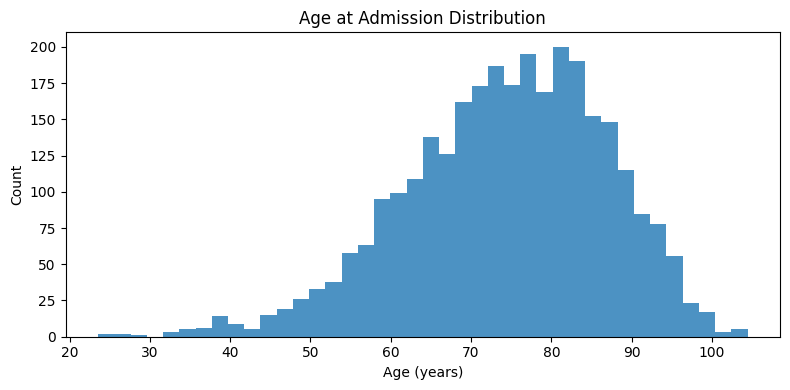

In [3]:
# Age distribution (at admission)
if {'date_of_birth', 'admission_date'}.issubset(residents.columns):
    age_at_admission = (residents['admission_date'] - residents['date_of_birth']).dt.days / 365.25
    age_at_admission = age_at_admission.dropna()

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(age_at_admission, bins=40, alpha=0.8)
    ax.set_title('Age at Admission Distribution')
    ax.set_xlabel('Age (years)')
    ax.set_ylabel('Count')
    plt.tight_layout()
    plt.show()


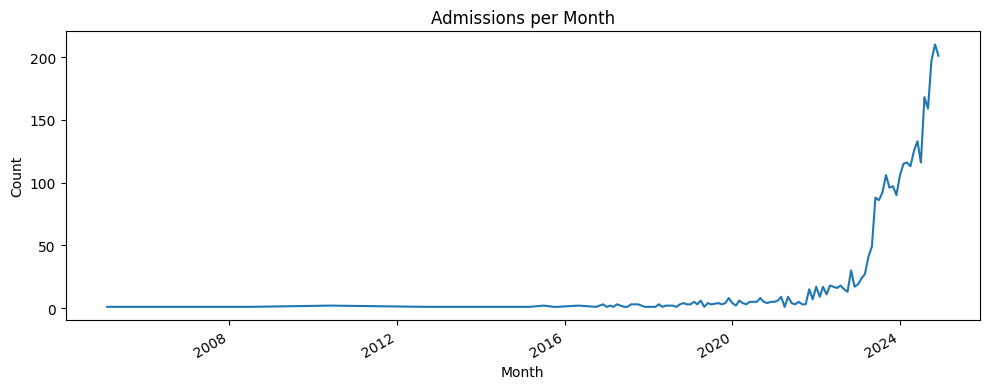

In [4]:
# Admissions over time
if 'admission_date' in residents.columns:
    adm_month = residents.dropna(subset=['admission_date']).copy()
    adm_month['month'] = adm_month['admission_date'].dt.to_period('M').dt.to_timestamp()
    s = adm_month.groupby('month').size()

    fig, ax = plt.subplots(figsize=(10, 4))
    s.plot(ax=ax)
    ax.set_title('Admissions per Month')
    ax.set_xlabel('Month')
    ax.set_ylabel('Count')
    plt.tight_layout()
    plt.show()


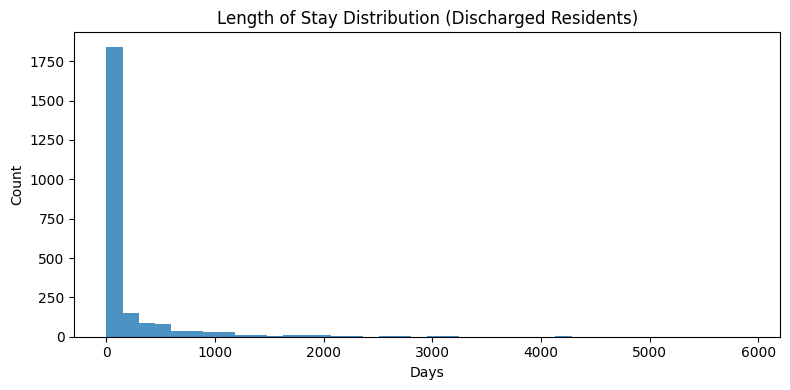

LOS median days: 31.0
LOS p90 days: 572.3000000000002


In [5]:
# Length of stay for discharged residents
if {'admission_date', 'discharge_date'}.issubset(residents.columns):
    los = (residents['discharge_date'] - residents['admission_date']).dt.days
    los = los.dropna()

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(los.clip(lower=0), bins=40, alpha=0.8)
    ax.set_title('Length of Stay Distribution (Discharged Residents)')
    ax.set_xlabel('Days')
    ax.set_ylabel('Count')
    plt.tight_layout()
    plt.show()

    print('LOS median days:', los.median())
    print('LOS p90 days:', los.quantile(0.9))


## Business Ideas This Table Can Answer

- Resident churn dynamics: admission vs discharge pressure by period/facility.
- Exposure duration: resident-time denominator for claim-rate normalization.
- Demographic risk context: age structure shifts over time.
- Capacity stress signals: spikes in admissions/discharges.
